# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 3, <font color="blue">легкая часть</font>. Линейная и логистическая регрессии.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко. 
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):

* Задача 1 &mdash; 20 баллов
* Задача 2 &mdash; 80 баллов
* Задача 3 &mdash; 30 баллов;
* Задача 4 &mdash; 20 баллов;

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):

* Задачи 5-7: скачайте второй ноутбук с условием задания со страницы курса.

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [1]:
# Bot check

# HW_ID: fpmi_ad3_part1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")

При решении задания используйте `sklearn`. Пропишите сюда необходимые импорты

In [75]:
from typing import Tuple, Optional, Any, Dict, List
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

sns.set(font_scale=1.3, palette="Set2")
RANDOM_STATE = 42  # фиксируем зерно случайности
CURR_DATE = str(datetime.now().date())  # сегодняшняя дата
DAYS_PER_YEAR = 365  # количество дней в году
pd.options.mode.chained_assignment = None

---
### <font color="blue"><i>Легкая часть</i></font>

---
### Задача 1.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 146d04157c07b08ee58d3eafdcf82c32 -->
Рассмотрим модель одномерной линейной регрессии *без свободного параметра* $y(x) = \theta x$, где $x\in \mathbb{R}$ и $\theta \in \mathbb{R}$. Предполагаем, что данные получены по правилу
$$Y_i = \theta x_i + \varepsilon_i,$$
где $i \in \{1, ..., n\}$, числа $x_i \in \mathbb{R}$ неслучайны, а $\varepsilon_i$ &mdash; случайные ошибки.

**1.** Посчитайте оценку $\widehat{\theta}$ методом наименьших квадратов по явной формуле.

**2.** Выпишите формулы итераций градиентного спуска (GD) и стохастического градиентного спуска (SGD) для поиска $\widehat{\theta}$. Не забудьте указать, как в SGD математически определяется батч (набор объектов на каждой итерации).

**3.** Опишите, что произойдет, если для некоторого $i$ ошибка $\varepsilon_i$ будет очень большой.


*Замечания.*
1. Это теоретическая задача, не перепутайте 😄
2. В ответе во всех пунктах могут оставаться суммы $n$ слагаемых, но не должно быть операций с векторами или матрицами.
3. **Прочитайте требования к формату решения в правилах сдачи задания.**

**Решение:**
**1** $$\hat{\theta} = (X^T X)^{-1}\cdot X^TY = (\sum_{i = 1}^n x_i^2)^{-1} (\sum_{i = 1}^{n} x_i\cdot y_i) = \cfrac{\sum_{i = 1}^{n} x_i\cdot y_i}{\sum_{i = 1}^n x_i^2}$$

**2.** GD $$\theta_{t + 1} = \theta_t - \eta X^T(X \theta_t - Y) = \theta_t (1 - \eta\sum_{i = 1}^n x_i^2) - \eta(\sum_{i = 1}^n x_iy_i)$$

**3** SGD $$\theta_{t + 1} = \theta_t - \eta \cfrac{n}{k} X^T_I(X_I \theta_t - Y_I) = \theta_t (1 - \eta\ \cfrac{n}{k}\sum_{i \in I} x_i^2) - \eta\cfrac{n}{k}(\sum_{i \in I} x_iy_i)$$
Батч - Это набор $I = \{i_1, \dots, i_k\}$, где $i_1, \dots, i_k \in \overline{1, n}$ и выбираются случайно на каждом шаге (могут быть повторы)

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
---
### Задача 2.

*Перед выполнением задачи ознакомтесь с <a href="https://thetahat.ru/courses/ad/main/3/ad_linreg_sklearn">ноутбуком по линейной регрессии</a> с занятия.*

Скоро весна и лето &mdash; идеальное время года для путешествий и прогулок на велосипедах. В крупных городах обычно развиты сети проката велосипедов или самокатов, предоставляющие удобный сервис. Одной из важных задач таких компаний является прогнозирование количества арендованных велосипедов в зависимости от времени года и погодных условий.

Рассмотрим датасет <a target="_blank" href="https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset">Bike Sharing Dataset</a> от компании <a target="_blank" href="https://www.capitalbikeshare.com/">Capital Bikeshare</a>, располагающей автоматизированными пунктами проката велосипедов. В датасете по дням записаны календарная информация и погодные условия, а также число прокатов в этот день. Цель &mdash; предсказать количество арендованных велосипедов по остальным характеристикам.

<img src="https://thetahat.ru/files/ad/main/3/bike1.jpeg">

Будем работать только со следующими признаками:
* `season`: время года: 1 &mdash; зима, 2 &mdash; весна, 3 &mdash; лето, 4 &mdash; осень;
* `mnth`: месяц от 1 до 12;
* `holiday`: является ли текущий день праздничным;
* `weekday`: день недели от 0 до 6;
* `workingday`: является ли текущий день рабочим или выходным;
* `weathersit`: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман);
* `temp`: температура в Цельсиях;
* `atemp`: температура по ощущениям в Цельсиях;
* `hum`: влажность воздуха;
* `windspeed`: скорость ветра;
* `cnt`: количество арендованных велосипедов в текущий день.

---

Скачайте данные, загрузите их с помощью `pandas` и разделите на обучающую и тестовую части в соотношении 4:1. Далее всю аналитику необходимо проводить только на обучающей части данных.

In [8]:
# Загрузка данных в day
day = pd.read_csv(r"D:\MIPT\Semester_4\AD\bike+sharing+dataset\day.csv")
day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [9]:
# Деление на нужные признаки
day = day[["season", "mnth", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed", "cnt"]]

In [37]:
# Деление на тренировочную и тестовую выборки
train_day, test_day = train_test_split(day, train_size = 0.8, random_state=42)

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 7e2346d718d374e3f957928b573e2a30 -->
#### 1. Визуальный анализ

Посмотрите по графикам, как *целевой признак зависит от остальных* и поймите характер этой зависимости. Старайтесь строить информативные графики, а из финального решения убирать те, которые не пригодились.

Какие признаки категориальные, а какие &mdash; вещественные? Учтите это при построении информативных графиков.

*Указание*. Среди признаков есть такие, значения которых как-то упорядочены, и их относительно небольшое количество. Чтобы понять, являются ли они категориальными, попробуйте понять, как с их значениями будут работать линейные модели. Иначе говоря, допустимо ли с точки зрения природы данных выполнять арифметические операции между *любыми* значениями этого признака, согласуется ли это со смыслом, который несет в себе данный признак?

In [7]:
# Категориальные признаки отличаются от вещественных по одному несложному признаку: осмысленность операции сложения.
# Таким образом, можно разделить признаки на осмысленные и неосмысленные по сложению.
# Категориальные: от сезона до погодных условий. Вещественные: от температуры до скорости ветра.

In [8]:
# Для котегориальных признаков лучше подходят информативные графики типа boxplot

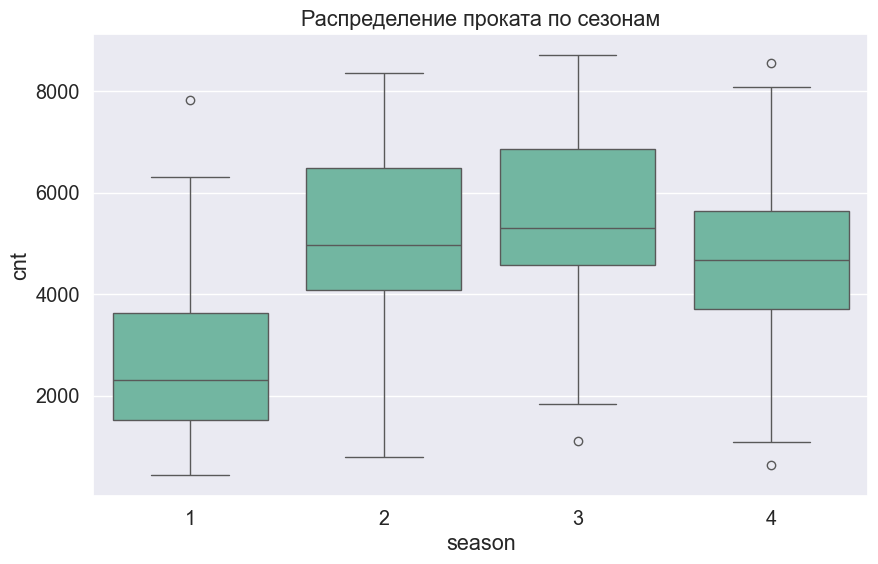

In [38]:
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'season', y = 'cnt', data = train_day)
plt.title('Распределение проката по сезонам')
plt.show()

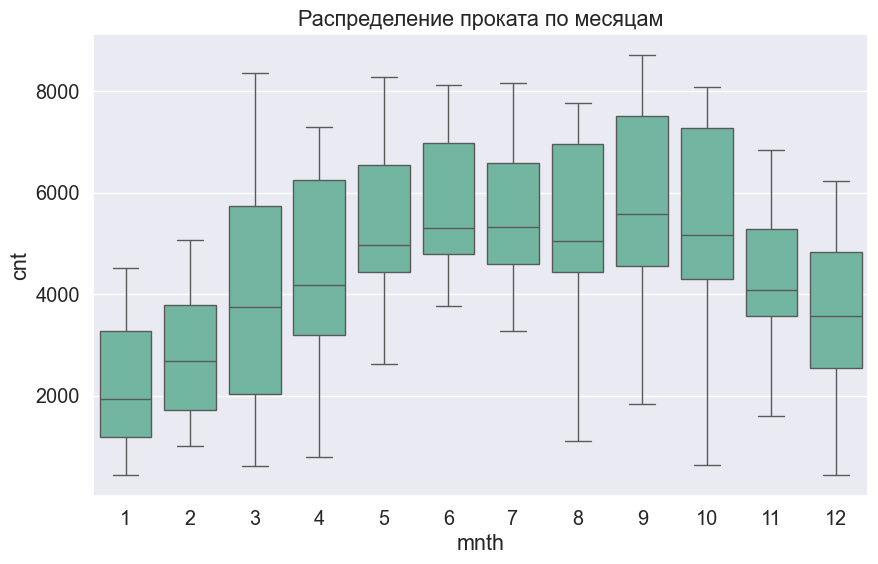

In [39]:
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'mnth', y = 'cnt', data = train_day)
plt.title('Распределение проката по месяцам')
plt.show()

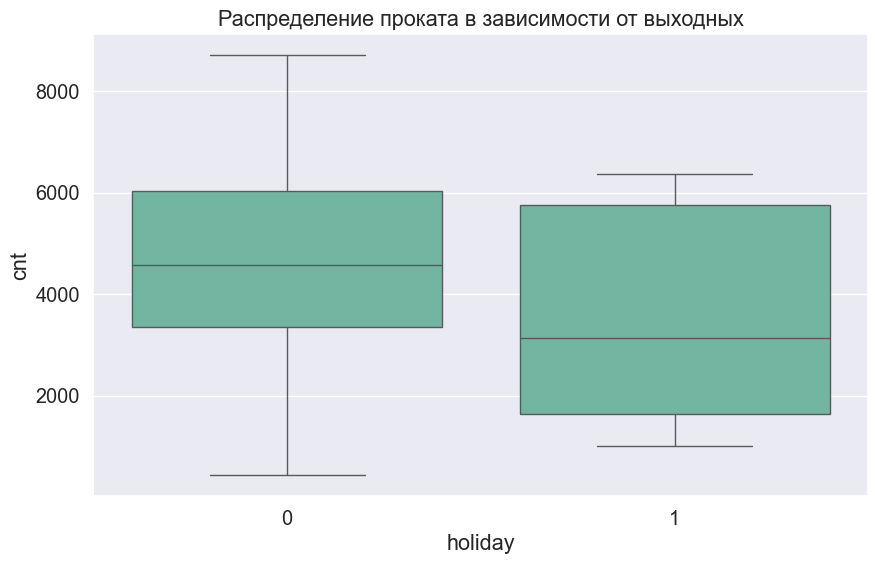

In [40]:
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'holiday', y = 'cnt', data = train_day)
plt.title('Распределение проката в зависимости от выходных')
plt.show()

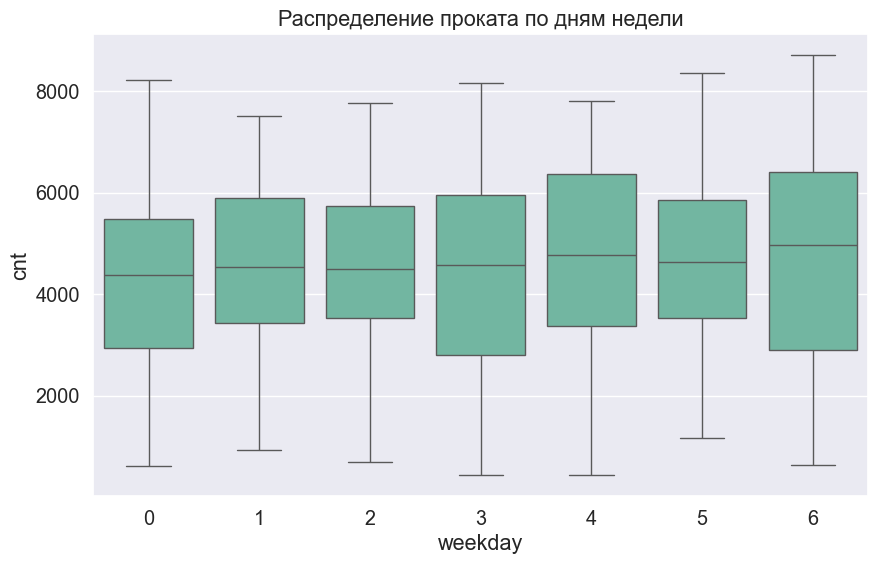

In [41]:
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'weekday', y = 'cnt', data = train_day)
plt.title('Распределение проката по дням недели')
plt.show()

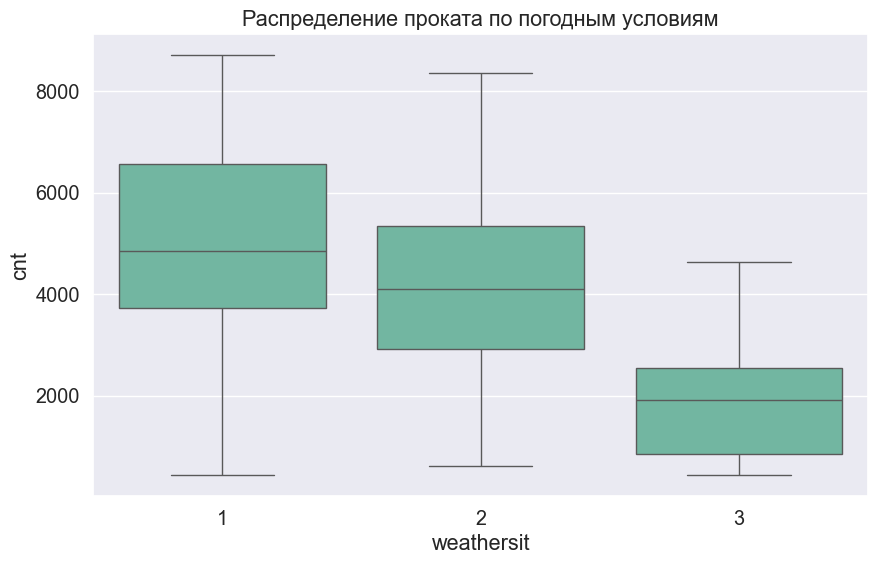

In [42]:
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'weathersit', y = 'cnt', data = train_day)
plt.title('Распределение проката по погодным условиям')
plt.show()

In [14]:
# В общем ситуацию можно охарактеризовать как ожидаемую: чем лучше погода, тем больше прокат. 
# Также заметно, что в непраздничные дни прокат выше, а в 6-ой день недели самая высока медиана по параметру cnt. Эти факты вкупе наводят на мысль, что 
# велосипеды в основном используются, чтобы доехать до работы/учёбы и покататься в субботу.

In [15]:
# для вещественных признаков лучше подходят графики типа kdeplo

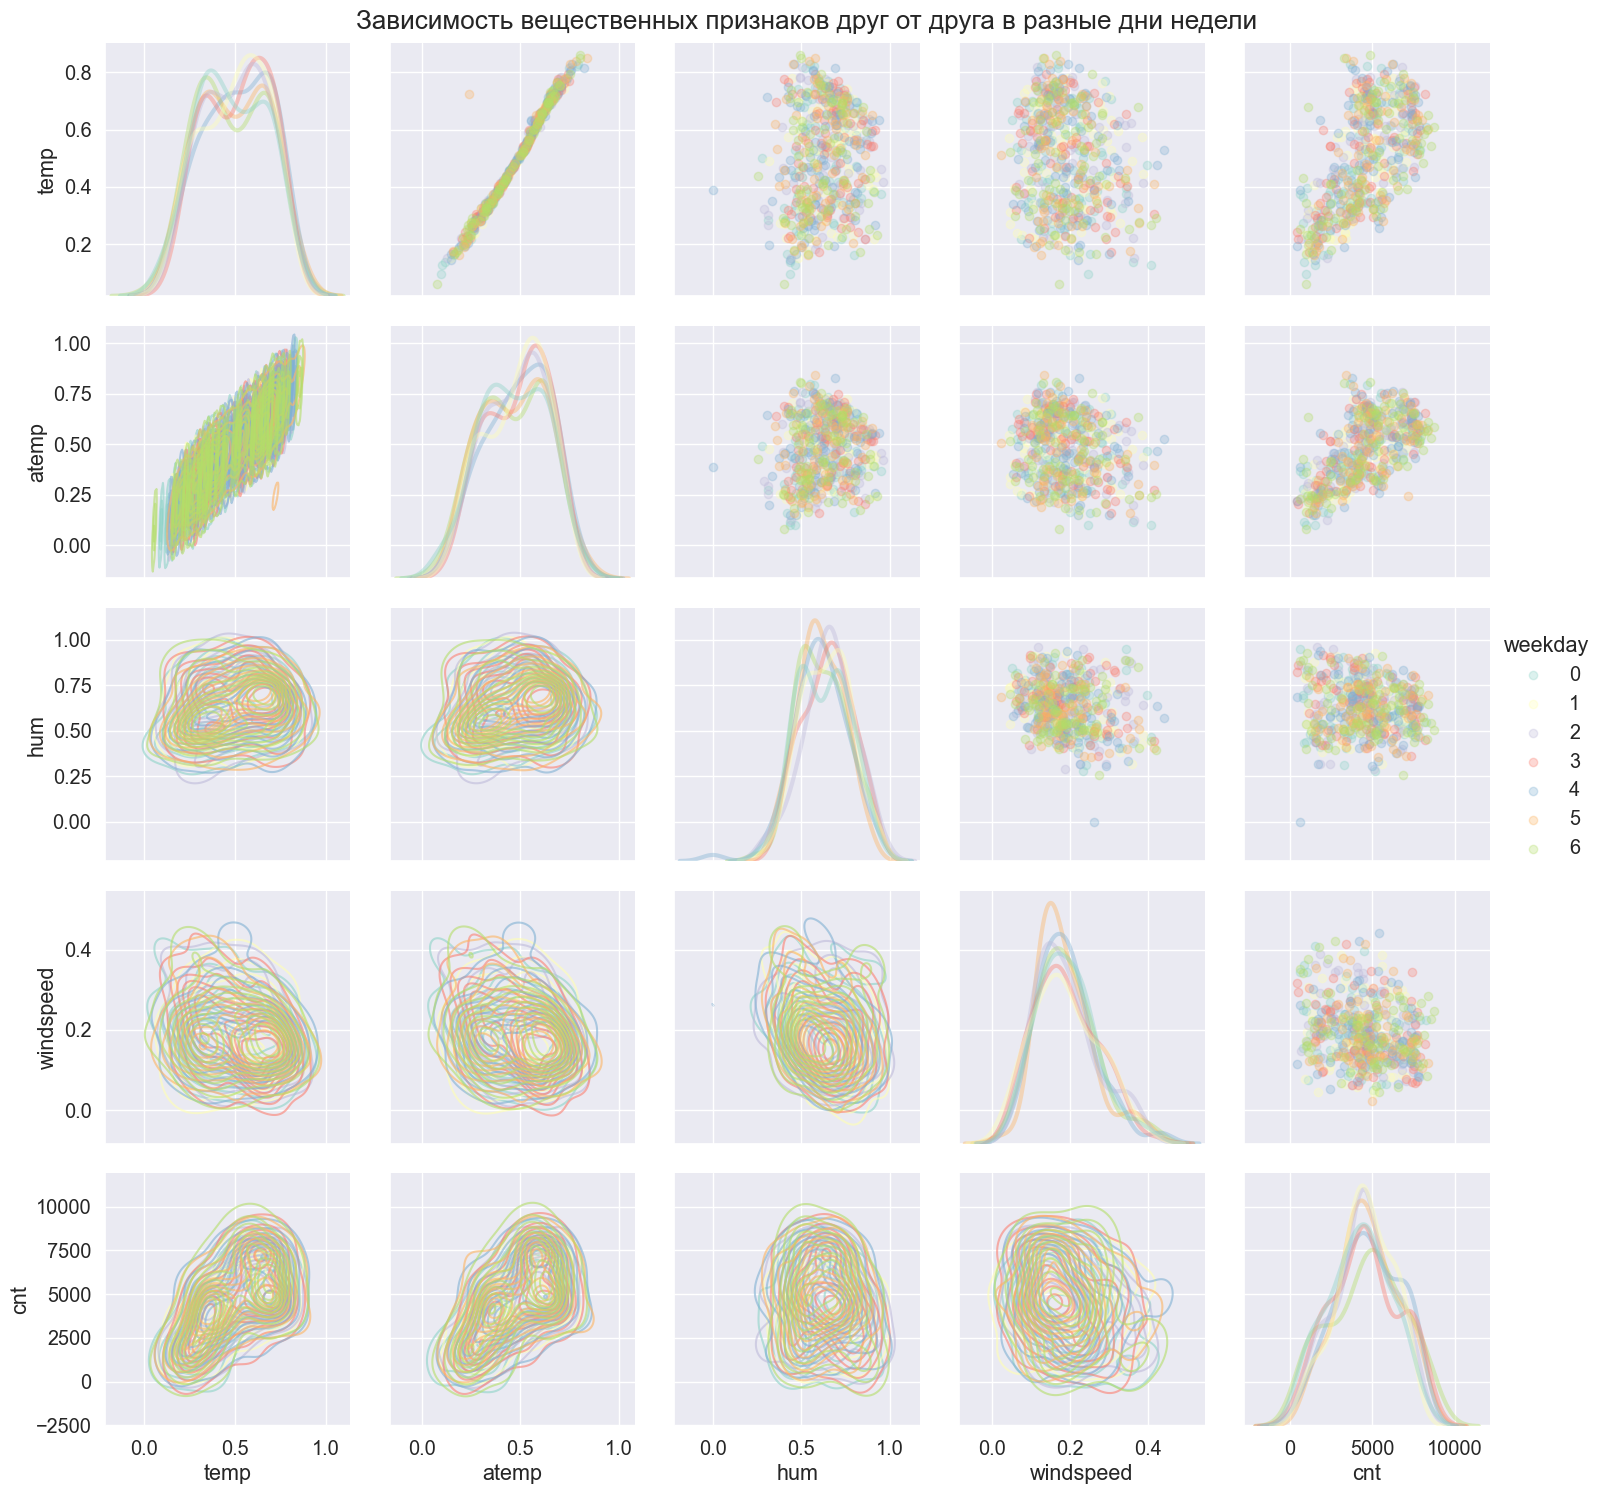

In [43]:
g = sns.PairGrid(
    train_day[["temp", "atemp", "hum", "windspeed", "cnt", "weekday"]],
    hue = "weekday",
    diag_sharey = False,
    height = 3,
    palette = "Set3"
)

g.map_lower(sns.kdeplot, alpha = 0.6, color = ".1")
g.map_upper(plt.scatter, alpha = 0.3)
g.map_diag(sns.kdeplot, lw = 3, alpha = 0.4, common_norm = False, color = '.1')
g.fig.suptitle("Зависимость вещественных признаков друг от друга в разные дни недели", y = 1)

g.add_legend()

In [17]:
# Из графика видно, что целевой признак наиболее чувствителен к температуре по сравнению с другими.
# Причём зависимость от температуры (ощущаемой температуры) линейно аппроксимируется.
# Заметна естественно предполлагаемая прямая зависимость темпереатуры от ощущаемой
# Дни недели в целом слабо влияют. На фоне других немного выделяется 6-ой день в сторону большего количества прокатов.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 4c1edb365b02e434e38deeb52b2096fa -->
Сделайте выводы по графикам. В частности, ответьте на следующие вопросы.
* Есть ли в данных явные выбросы, то есть точки, далеко находящиеся от основной массы точек?
* Стоит ли рассматривать какие-либо нелинейные функции от признаков? Не стоит придумывать сложные функции, достаточно рассмотреть $x^2$, $\log x$ и $I\{x > c\}$.



**Выводы по графикам:** 
**1** Да, есть. Они определяются по границам типа "T" и выколотым точкам на графиках категориальных признаков, и видны как далёкие точки на графиках вещественных признаков.
**2** В некоторых графиках категориальных признаков наблюдается периодичность, поэтому стоит рассмотреть периодические функции, например с периодом 12 месяцев. В графиках вещественных признаков не стоит рассматривать сложных функций.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- e5fcb54a72af33e2c09b66124e63e5fc -->
#### 2. Подготовка данных

Опишите по шагам процедуру предобработки данных, которая будет включать работу с выбросами, преобразования вещественных и категориальных признаков, возможно, создание каких-либо новых признаков (посмотрите <a href="https://thetahat.ru/courses/ad/main/3/ad_linreg_sklearn">пример</a> с занятия). То, как именно выполнять подготовку данных, является целым исскуством. Здесь нет "правильного" подхода, здесь есть метрика качества на тестовом множестве, которая в последствии оценит качество вашей модели.

*Обратите внимание, от того, насколько качественно вы проведете визуальный анализ и подготовку данных, будет зависеть качество ваших моделей на следующих шагах.*

**Процедура предобработки данных:**

**a).** Убрать все выбросы по визуальной оценке графиков.

**б).** Убрать один из сильно коррелирующих признаков: temp (atemp), season (mnth), workingday (holiday, weekday). (По идее можно составить карту корреляции, но тут и так всё видно)

**в).** Закодировать все категориальные признаки с помощью One Hot Encoder

Реализуйте данную процедуру.

In [44]:
# Работа с выбросами
train_day = train_day[train_day["hum"] > 0.25]
train_day = train_day[train_day["windspeed"] < 0.5]
train_day = train_day[(train_day["temp"] / train_day["atemp"] < 1.3) & (train_day["temp"] / train_day["atemp"] > 0.7)]
train_day = train_day[train_day["weathersit"] <= 4] # слишком мало таких дней, поэтому они не дают статистику

In [45]:
# Без season, без temp, и без workingday
train_day = train_day[["mnth", "holiday", "weekday", "weathersit", "atemp", "hum", "windspeed", "cnt"]]

In [46]:
train_day

,mnth,holiday,weekday,weathersit,atemp,hum,windspeed,cnt
682,11,0,2,2,0.323225,0.662917,0.342046,4094
250,9,0,4,3,0.555361,0.939565,0.192748,1842
336,12,0,6,1,0.310604,0.612917,0.095783,3614
260,9,0,0,1,0.490537,0.695000,0.178483,4274
543,6,0,3,1,0.640792,0.360000,0.271775,7335
...,...,...,...,...,...,...,...,...
71,3,0,0,1,0.380091,0.527391,0.270604,2417
106,4,0,0,1,0.445696,0.479583,0.303496,3744
270,9,0,3,2,0.575158,0.848750,0.148629,3907
435,3,0,0,1,0.359670,0.476957,0.222587,4911


In [47]:
# вещественизируем категориальные признаки
encoder = OneHotEncoder(drop="first", sparse_output=False)
categorial_features = ["mnth", "holiday", "weekday", "weathersit"]
train_cat = encoder.fit_transform(train_day[categorial_features])
train_cat

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.]], shape=(582, 20))

In [48]:
encoder.categories_

[array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 array([0, 1]),
 array([0, 1, 2, 3, 4, 5, 6]),
 array([1, 2, 3])]

In [49]:
# соединим преобразованные признаки в одну таблицу с вещественными признаками
real_features = ["atemp", "hum", "windspeed"]
X_train = np.hstack([train_day[real_features], train_cat])

In [50]:
# проверим
X_train

array([[0.323225 , 0.662917 , 0.342046 , ..., 0.       , 1.       ,
        0.       ],
       [0.555361 , 0.939565 , 0.192748 , ..., 0.       , 0.       ,
        1.       ],
       [0.310604 , 0.612917 , 0.0957833, ..., 1.       , 0.       ,
        0.       ],
       ...,
       [0.575158 , 0.84875  , 0.148629 , ..., 0.       , 1.       ,
        0.       ],
       [0.35967  , 0.476957 , 0.222587 , ..., 0.       , 0.       ,
        0.       ],
       [0.417283 , 0.819167 , 0.250617 , ..., 0.       , 1.       ,
        0.       ]], shape=(582, 23))

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- c5124704b109dacbd9cf5647f50eb72c -->
#### 3. Обучение модели и ее анализ

Обучите линейную регрессию из `sklearn` на полученных данных и посмотрите на полученные оценки коэффициентов (в т.ч. свободный коэффициент).

In [51]:
# Обучим модель, используя категориальные и вещественные признаки
model_full = LinearRegression(fit_intercept=True)
model_full.fit(X_train, train_day["cnt"])

LinearRegression()

In [52]:
# Выведем коэффициенты
coefficients = model_full.coef_
intercept = model_full.intercept_

print("Коэффициенты модели:", np.round(coefficients, 2))
print("Свободный член (intercept):", np.round(intercept, 2))

Коэффициенты модели: [ 8.13669e+03 -3.64145e+03 -3.09787e+03  7.30000e+00  7.82850e+02
  6.04010e+02  8.43630e+02  2.02910e+02 -5.98410e+02 -9.02400e+01
  1.24551e+03  1.60013e+03  1.16494e+03  8.57830e+02 -7.72000e+02
  3.45920e+02  2.61970e+02  2.54590e+02  2.73680e+02  4.03050e+02
  4.66760e+02 -1.34250e+02 -1.38213e+03]
Свободный член (intercept): 2826.57


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 0e8e860f57fc7df75f236442f7206c78 -->
Посчитайте ошибку предсказания на тестовой выборке по метрикам RMSE, MAE, MAPE. Подробнее можно почитать в <a href="https://thetahat.ru/courses/ad/main/3/ad_linreg_sklearn">ноутбуке</a> с занятия.

*Замечание.* Если в тестовой части тоже есть "большие" выбросы, их стоит убрать. Наша модель не должна пытаться их предсказать (например, сбои в работе сервиса) но в то же время выбросы вносят существенный вклад в значение метрики. Особенно стоит обратить на это внимание в случае высоких значений метрик.

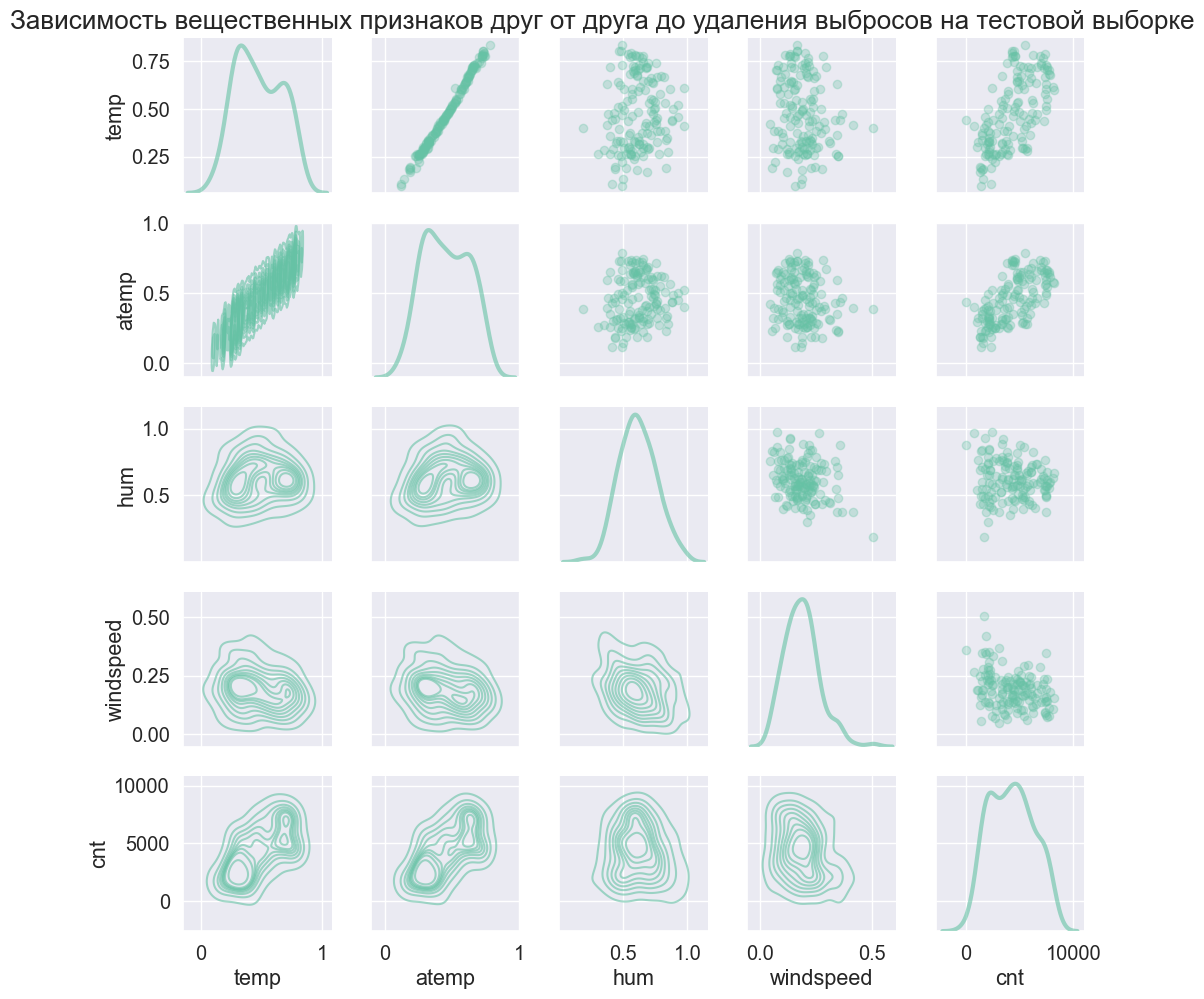

In [53]:
# Визуализируем вещественные признаки тестовых данных
g = sns.PairGrid(
    test_day[["temp", "atemp", "hum", "windspeed", "cnt"]], diag_sharey=False, height=2,
)

g.map_lower(sns.kdeplot, alpha=0.6)
g.map_upper(plt.scatter, alpha=0.3)
g.map_diag(sns.kdeplot, lw=3, alpha=0.6, common_norm=False)
g.fig.suptitle("Зависимость вещественных признаков друг от друга до удаления выбросов на тестовой выборке", y=1)

g.add_legend()

In [54]:
# выбросы визуально заметны только в столбце hum, исправим их:
test_day = test_day[test_day["hum"] > 0.2]

Для оценки модели нам нужно сначала закодировать тестовые данные так же, как это делали с тренировочными, но без fit

In [55]:
# инкодинг
test_cat = encoder.transform(test_day[categorial_features])
X_test = np.hstack([test_day[real_features], test_cat])

In [56]:
# предсказанные данные для тестового набора
test_preds = model_full.predict(X_test)

In [57]:
# Оценка по метрикам
print(round(metrics.mean_squared_error(test_day["cnt"], test_preds) ** 0.5, 2)) # RMSE
print(round(metrics.mean_absolute_error(test_day["cnt"], test_preds), 2)) # MAY
print(round(metrics.mean_absolute_percentage_error(test_day["cnt"], test_preds), 2)) # MAPY

1392.48
1189.38
1.17


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 82920a034ed2865f8a7e2f03eaabceb6 -->
Попробуйте посчитать оценку коэффициентов с помощью формулы, полученной на занятии. Не забудьте про константный признак. В чем заключается проблема?

*Подсказка.* Подумайте о зависимостях между признаками. Причем, возможно, вы уже могли решить эту проблему на предыдущих этапах. В таком случае посмотрите, что будет, если "вернуть" проблему.

In [59]:
# Для исправности работы с константным признаком, необходимо добавить столбец из 1 к X_train
Y = train_day["cnt"]
X = np.hstack((np.ones((582, 1)), X_train))
Theta = np.linalg.inv((X.T @ X)) @ X.T @ Y

#Посмотрим на коэффициенты
print(Theta)

[ 2.82656893e+03  8.13668572e+03 -3.64144723e+03 -3.09787412e+03
  7.29809528e+00  7.82851577e+02  6.04007108e+02  8.43631704e+02
  2.02913748e+02 -5.98411170e+02 -9.02362481e+01  1.24551106e+03
  1.60013203e+03  1.16494397e+03  8.57826530e+02 -7.71996467e+02
  3.45919257e+02  2.61974321e+02  2.54591203e+02  2.73681768e+02
  4.03049998e+02  4.66762294e+02 -1.34250664e+02 -1.38212723e+03]


In [60]:
# предсказания, вычисленные по формуле с лекции на тестовых данных
predicts = (np.hstack((np.ones((X_test.shape[0], 1)), X_test))) @ Theta

In [61]:
# Оценка по метрикам
print(round(metrics.mean_squared_error(test_day["cnt"], predicts) ** 0.5, 2)) # RMSE
print(round(metrics.mean_absolute_error(test_day["cnt"], predicts), 2)) # MAY
print(round(metrics.mean_absolute_percentage_error(test_day["cnt"], predicts), 2)) # MAPY

1392.48
1189.38
1.17


Как видно, ошибка низка. Такой результат получен благодаря грамотному выбору данных.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 56aff27d604dbe90dda7b28a8da4e2e9 -->
Исправьте эту проблему, посчитайте оценки коэффициентов, а также ошибку предсказания.

Посмотрим, что будет, если вернуть проблему.

In [62]:
# разделяем выборки
prob_train_day, prob_test_day = train_test_split(day, train_size = 0.8, random_state=42)

In [63]:
# Работа с выбросами
prob_train_day = prob_train_day[prob_train_day["hum"] > 0.25]
prob_train_day = prob_train_day[prob_train_day["windspeed"] < 0.5]
prob_train_day = prob_train_day[(prob_train_day["temp"] / prob_train_day["atemp"] < 1.3) & (prob_train_day["temp"] / prob_train_day["atemp"] > 0.7)]
prob_train_day = prob_train_day[prob_train_day["weathersit"] <= 4] # слишком мало таких дней, поэтому они не дают статистику

In [64]:
# вещественизируем категориальные признаки
prob_encoder = OneHotEncoder(drop="first", sparse_output=False)
prob_categorial_features = ["season", "workingday", "mnth", "holiday", "weekday", "weathersit"]
prob_train_cat = prob_encoder.fit_transform(prob_train_day[prob_categorial_features])
prob_train_cat

array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(582, 24))

In [65]:
# соединим преобразованные признаки в одну таблицу с вещественными признаками
prob_real_features = ["temp", "atemp", "hum", "windspeed"]
prob_X_train = np.hstack([prob_train_day[prob_real_features], prob_train_cat])

In [66]:
# Обучим модель, используя категориальные и вещественные признаки
prob_model_full = LinearRegression(fit_intercept=True)
prob_model_full.fit(prob_X_train, prob_train_day["cnt"])

LinearRegression()

In [67]:
# выбросы визуально заметны только в столбце hum, исправим их:
prob_test_day = prob_test_day[prob_test_day["hum"] > 0.2]

In [68]:
# инкодинг
prob_test_cat = prob_encoder.transform(prob_test_day[prob_categorial_features])
prob_X_test = np.hstack([prob_test_day[prob_real_features], prob_test_cat])

In [69]:
# предсказанные данные для тестового набора
prob_test_preds = prob_model_full.predict(prob_X_test)

In [70]:
# Оценка по метрикам
print(round(metrics.mean_squared_error(prob_test_day["cnt"], prob_test_preds) ** 0.5, 2)) # RMSE
print(round(metrics.mean_absolute_error(prob_test_day["cnt"], prob_test_preds), 2)) # MAY
print(round(metrics.mean_absolute_percentage_error(prob_test_day["cnt"], prob_test_preds), 2)) # MAPY

1359.6
1174.14
1.17


In [71]:
# Для исправности работы с константным признаком, необходимо добавить столбец из 1 к X_train
Y = prob_train_day["cnt"]
X = np.hstack((np.ones((prob_X_train.shape[0], 1)), prob_X_train))
Theta = np.linalg.inv((X.T @ X)) @ X.T @ Y

In [72]:
# предсказания, вычисленные по формуле с лекции на тестовых данных
prob_predicts = (np.hstack((np.ones((prob_X_test.shape[0], 1)), prob_X_test))) @ Theta

In [73]:
# Оценка по метрикам
print(round(metrics.mean_squared_error(prob_test_day["cnt"], prob_predicts) ** 0.5, 2)) # RMSE
print(round(metrics.mean_absolute_error(prob_test_day["cnt"], prob_predicts), 2)) # MAY
print(round(metrics.mean_absolute_percentage_error(prob_test_day["cnt"], prob_predicts), 2)) # MAPY

196679.79
144164.71
117.35


Как видно, ошибка велика.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 52266029600cdfda3b1cfce9e68f5c99 -->
Сделайте выводы.

**Выводы:**
Были визуализированы и исследованы данные. По визуальным оценкам были откинуты выбросы, а по логическим соображениям коррелирующие признаки. Была обучена линейная модель двумя способами: с помощью библиотеки SKlearn, формулы с лекции. Точность результатов по формуле и по модели совпадают. В случае, если не учтены корреляции признаков, точность формулы сильно падает.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
*Замечание.* Не расстраивайтесь, если у вас получится не очень хорошее качество, это нормально. Вы провели только небольшую предобработку данных и обучили *простую* модель. Более сложные методы обработки данных и обучения ждут вас впереди. Главное &mdash; с чего-то начать!

<img src="https://thetahat.ru/files/ad/main/3/bike2.png">

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2c0205cf5ab3ec02c6ea667faa01e48b -->
---
### Задача 3.

*Перед выполнением задачи ознакомтесь с <a href="https://thetahat.ru/courses/ad/main/3/ad_logreg_sklearn">ноутбуком по логистической регрессии</a> с занятия.*

> Одно из интересных свойств модели логистической регрессии — *при соблюдении её предположений* она дает возможность получать **несмещенные оценки вероятностей** принадлежности объекта к определенному классу.  
> Для пояснения рассмотрим объект $x$ и соответствующее предсказание вероятности $\widehat{p}(x)$ для класса 1. Если взять небольшую окрестность объекта $x$, то доля объектов класса 1 в этой окрестности будет приблизительно равна $\widehat{p}(x)$.  

Далее проверим это свойство на конкретных примерах.

С помощью кода ниже сгенерируйте данные, состоящие из одного вещественного признака и бинарного таргета.

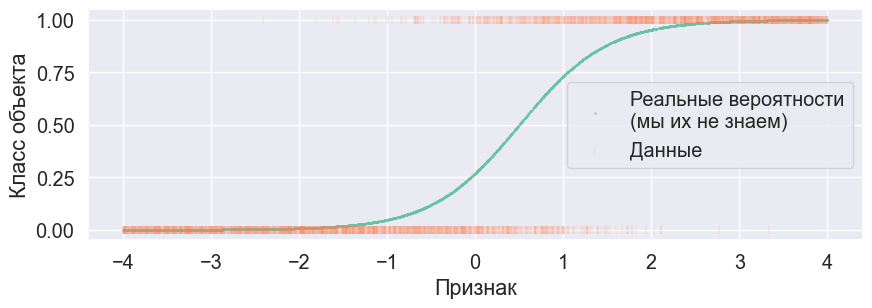

In [82]:
sample_size = 3000  # Размер выборки

# Признаки
X = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(1 - 2 * X.ravel()))
y = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности\n(мы их не знаем)")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

Обучите логистическую регрессию, используя реализацию из `sklearn`, при этом свободный коэффициент должен присутствовать в модели. Укажите также `penalty='none'`.

In [83]:
from sklearn.linear_model import LogisticRegression

In [84]:
# Логистическая регрессия
model = LogisticRegression(fit_intercept=True, penalty=None, max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000, penalty=None)

Напечатайте оценку коэффициентов

In [85]:
print("Свободный коэффициент:", model.intercept_)
print("Коэффициенты модели:", model.coef_)

Свободный коэффициент: [-0.96519389]
Коэффициенты модели: [[1.97818099]]


Ниже объявлена сетка значений признака. По этой сетке постройте
* предсказания классов,
* предсказания вероятностей класса 1.

Визуализируйте эти предсказания. На график стоит нанести также обучающую выборку.

In [86]:
X_grid = np.linspace(-4, 4, 10000).reshape((-1, 1))

# Предсказание классов и вероятностей
y_grid_proba = model.predict_proba(X_grid)[:, 1]  # Вероятности 
y_grid_pred = model.predict(X_grid)  # предсказанные классы

Визуализируем:

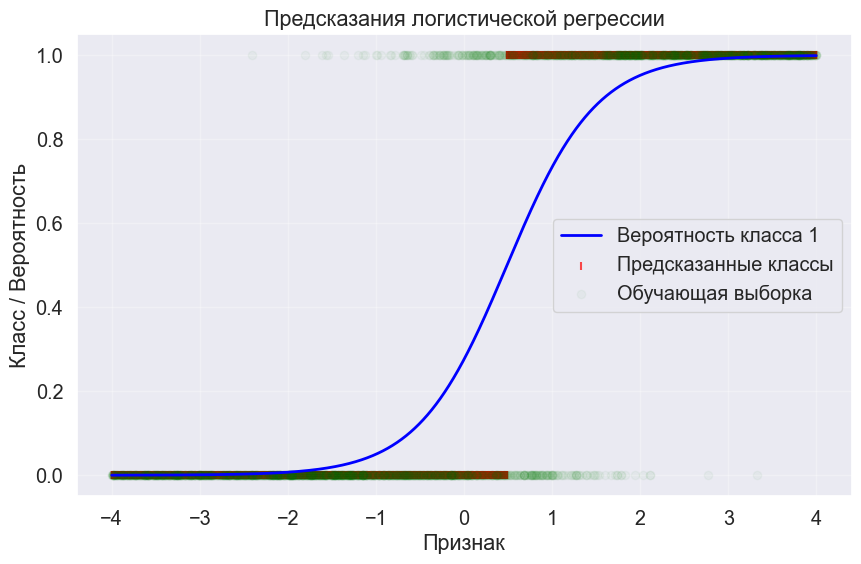

In [87]:
plt.figure(figsize=(10, 6))

# График предсказанных вероятностей
plt.plot(X_grid, y_grid_proba, label="Вероятность класса 1", color="blue", linewidth=2)

# График предсказанных классов
plt.scatter(X_grid, y_grid_pred, label="Предсказанные классы", color="red", alpha=0.7, marker="|")

# Обучающая выборка
plt.scatter(X, y, label="Обучающая выборка", color="green", alpha=0.03)

# Настройка графика
plt.xlabel("Признак")
plt.ylabel("Класс / Вероятность")
plt.title("Предсказания логистической регрессии")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Разбейте отрезок $[-4, 4]$ на одинаковые бины длины длины 0.2 и посчитайте в каждом бине долю объектов класса 1. Полученные значения добавьте на график предсказаний вероятностей и сравните эти графики. Проинтерпретируйте полученные результаты.

*Подсказка:* может помочь `np.digitize` и метод `groupby` для таблиц `pandas`. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.

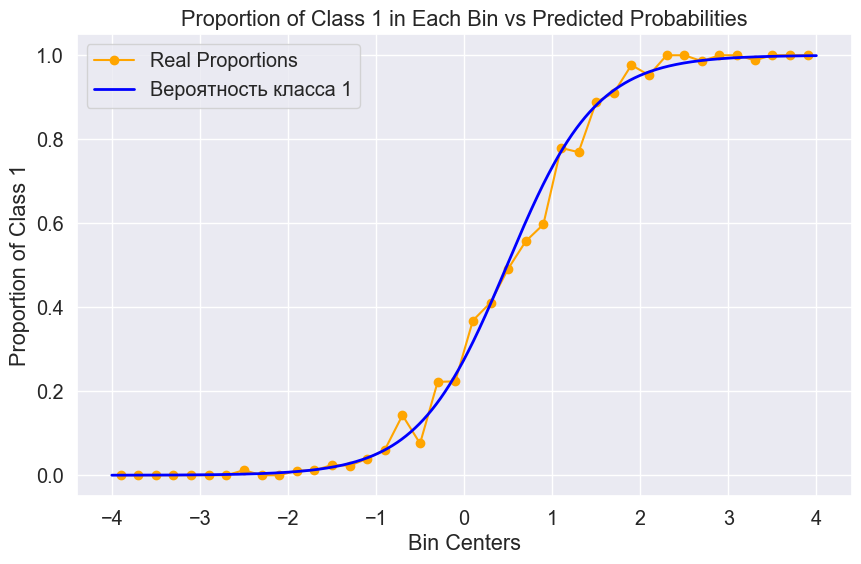

In [90]:
# Разбиение на бины
bin_width = 0.2
bins = np.arange(-4, 4 + bin_width, bin_width)  # Границы бинов
bin_centers = (bins[:-1] + bins[1:]) / 2  # Центры бинов

# Используем np.digitize для определения индексов бинов
bin_indices = np.digitize(X.ravel(), bins) - 1

# Создаем DataFrame для удобства работы с данными
df = pd.DataFrame({'bin_index': bin_indices, 'y': y})

# Группируем по индексам бинов и вычисляем долю объектов класса 1
real_proportions = df.groupby('bin_index')['y'].mean().values

# Заменяем NaN на 0 для бинов, в которых нет объектов
real_proportions = np.nan_to_num(real_proportions, nan=0.0)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, real_proportions, marker='o', linestyle='-', label='Real Proportions', color='orange')
plt.plot(X_grid, y_grid_proba, label="Вероятность класса 1", color="blue", linewidth=2)
plt.xlabel('Bin Centers')
plt.ylabel('Proportion of Class 1')
plt.title('Proportion of Class 1 in Each Bin vs Predicted Probabilities')
plt.legend()
plt.grid(True)
plt.show()

Реальные доли примерно соответствуют кривой реального распределения. Точки, где реальная доля класса 1 превышает 0,5 и где находится граница распределения моделью на классы, примерно совпадают.

Повторите проведенное исследование для следующих данных и сравните результаты.

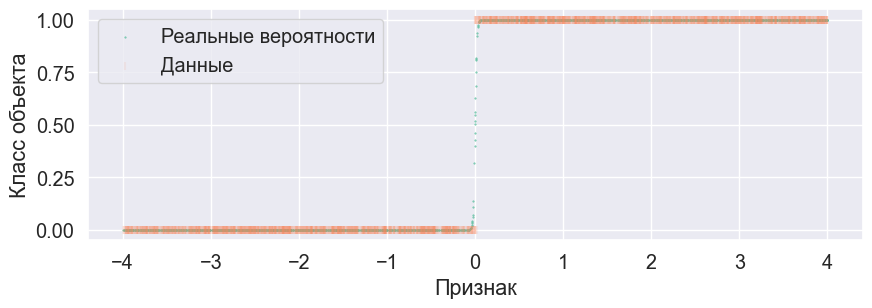

In [96]:
# Признаки
X = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(-100 * X.ravel()))
y = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

In [97]:
# Логистическая регрессия
model = LogisticRegression(fit_intercept=True, penalty=None, max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000, penalty=None)

In [98]:
# Оценка коэффициентов
print("Свободный коэффициент:", model.intercept_)
print("Коэффициенты модели:", model.coef_)

Свободный коэффициент: [-0.31070894]
Коэффициенты модели: [[46.45070356]]


Как видно, коэффициенты сильно отличаются от коэффициентов предыдущего исследования

In [99]:
X_grid = np.linspace(-4, 4, 10000).reshape((-1, 1))

# Предсказание классов и вероятностей
y_grid_proba = model.predict_proba(X_grid)[:, 1]  # Вероятности 
y_grid_pred = model.predict(X_grid)  # предсказанные классы

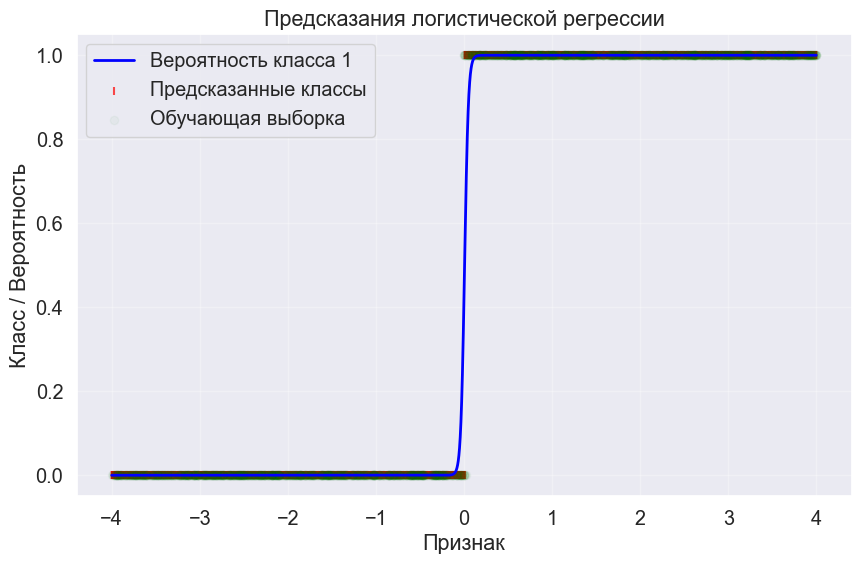

In [100]:
plt.figure(figsize=(10, 6))

# График предсказанных вероятностей
plt.plot(X_grid, y_grid_proba, label="Вероятность класса 1", color="blue", linewidth=2)

# График предсказанных классов
plt.scatter(X_grid, y_grid_pred, label="Предсказанные классы", color="red", alpha=0.7, marker="|")

# Обучающая выборка
plt.scatter(X, y, label="Обучающая выборка", color="green", alpha=0.03)

# Настройка графика
plt.xlabel("Признак")
plt.ylabel("Класс / Вероятность")
plt.title("Предсказания логистической регрессии")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Как видно в сравнении с предыдущим аналогичным графиком, модель поделила тестовые данные ровно в нуле, а не в точке 0,5 т.к. кривая вреоятности пересекает половину в окрестности нуля. 

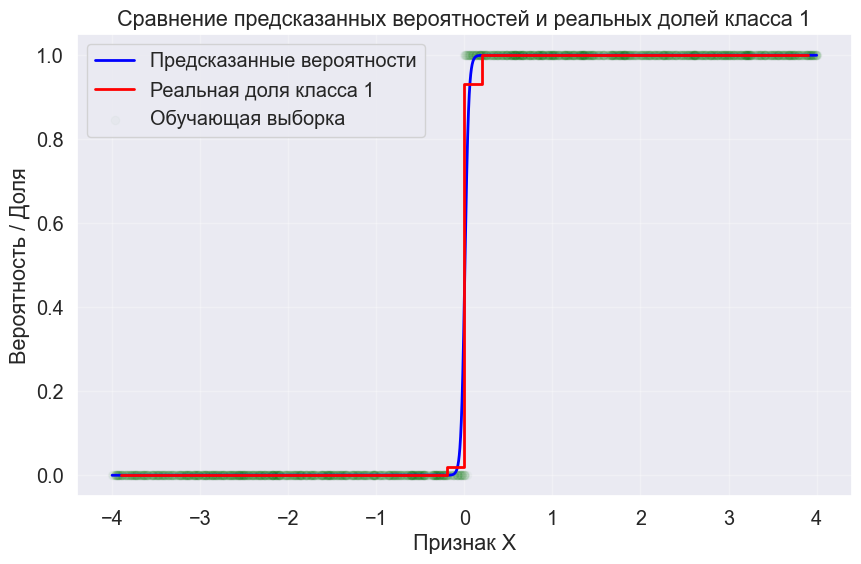

In [101]:
# Разбиение на бины
bin_width = 0.2
bins = np.arange(-4, 4 + bin_width, bin_width)  # Границы бинов
bin_centers = (bins[:-1] + bins[1:]) / 2  # Центры бинов

# Используем np.digitize для определения индексов бинов
bin_indices = np.digitize(X.ravel(), bins) - 1

# Создаем DataFrame для удобства работы с данными
df = pd.DataFrame({'bin_index': bin_indices, 'y': y})

# Группируем по индексам бинов и вычисляем долю объектов класса 1
real_proportions = df.groupby('bin_index')['y'].mean().values

# Заменяем NaN на 0 для бинов, в которых нет объектов
real_proportions = np.nan_to_num(real_proportions, nan=0.0)

# Визуализация
plt.figure(figsize=(10, 6))

# График предсказанных вероятностей
plt.plot(X_grid, y_grid_proba, color="blue", linewidth=2, label="Предсказанные вероятности")

# График реальных долей класса 1 в бинах
plt.step(bin_centers, real_proportions, where="mid", label="Реальная доля класса 1", color="red", linewidth=2)

# Обучающая выборка
plt.scatter(X, y, color="green", alpha=0.02, label="Обучающая выборка")

# Настройка графика
plt.xlabel("Признак X")
plt.ylabel("Вероятность / Доля")
plt.title("Сравнение предсказанных вероятностей и реальных долей класса 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Реальная доля классов лучше приближает кривую вероятности класса 1 в сравнении с предыдущим аналогичным графиком. Такой результат достигается благодаря сужению "переходной области". Так же как и в предыдущем исследовании, точки пересечение середины ломаной долей и модельным распределением примерно совпадают.

**Выводы:**

Было проведено исследование модели логистической регрессии с одним вещественным признаком и бинарным таргетом на различных обучающих данных. Была определена корреляция между долями точек класса 1 в бине и вердиктом модели. В целом модель довольно хорошо справилась с результатом: где теоретически предсказанная вероятность пересекала значение 0,5, там и проходила граница деления данных моделью на классы. Причём такой результат был достигнут на обоих наборах данных.

---
### Задача 4.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- f92a2876d3f2b0d01fc396776be023a9 -->
Продолжим исследовать модель логистической регрессии. Сгенерируем данные, состоящие из двух бинарных признаков и бинарного таргета

In [102]:
probs = np.random.uniform(size=8)
probs /= probs.sum()
probs

x = np.random.choice(np.arange(8), p=probs, size=10000)
data = pd.DataFrame(
    np.unpackbits(np.array(x.reshape(-1, 1), dtype=">i8").view(np.uint8), axis=1)[:, -3:],
    columns=["feature_1", "feature_2", "target"],
)
data.head()

,feature_1,feature_2,target
0,0,1,1
1,1,1,0
2,1,1,0
3,0,1,0
4,1,1,0


Особенность таких данных &mdash; конечное число *возможных различных* объектов. В данном случае их всего 4, по количеству всех возможных комбинаций значений признака. Соответственно, любой моделью мы можем сделать только 4 *различных* предсказания. Исследуем, как с этим справляется логистическая регрессия.

Сначала для сравнения посчитайте долю класса 1 для каждой категории объектов.

*Подсказка:* используйте `pd.pivot_table`. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.

В качестве агрегирующей функции используем среднее значение (mean) для столбца target, так как target бинарный (0 или 1), и среднее значение будет равно доле класса 1

In [103]:
# Сводная таблица
pivot_table = pd.pivot_table(
    data,
    values="target",  # Значения, которые мы агрегируем
    index="feature_1",  # Строки таблицы
    columns="feature_2",  # Столбцы таблицы
    aggfunc="mean",  # Среднее значение (доля класса 1)
)

# Вывод таблицы
print("Доля класса 1 для каждой комбинации признаков:")
print(pivot_table)

Доля класса 1 для каждой комбинации признаков:
feature_2         0         1
feature_1                    
0          0.252208  0.429314
1          0.551603  0.590430


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 14e68d57d58f901b3350e63f76b9f8db -->
Обучите логистическую регрессию с `penalty='none'` и получите предсказания вероятностей для этих четырех типов объектов. Представьте результаты в таком виде, чтобы их удобно было сравнивать с частотами, посчитанными ранее.

In [104]:
# Логистическая регрессия
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(data[["feature_1", "feature_2"]], data["target"])

LogisticRegression(max_iter=1000, penalty=None)

In [105]:
# Предсказания для каждой комбинации значений признаков
combinations = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
predicted_probs = model.predict_proba(combinations)[:, 1]

C:\Users\Name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [106]:
# DataFrame для удобства сравнения
comparison = pd.DataFrame({
    "feature_1": combinations[:, 0],
    "feature_2": combinations[:, 1],
    "predicted_prob": predicted_probs,  # Предсказанные вероятности принадлежности классу 1
})

In [107]:
# Добавляем реальные доли класса 1 из сводной таблицы
comparison = comparison.merge(
    pivot_table.reset_index().melt(id_vars="feature_1", var_name="feature_2", value_name="real_freq"),
    on=["feature_1", "feature_2"],
    how="left"
)

In [108]:
# Выводим результаты
print("Сравнение предсказанных вероятностей и реальных частот:")
print(comparison)

Сравнение предсказанных вероятностей и реальных частот:
   feature_1 feature_2  predicted_prob  real_freq
0          0         0        0.300838   0.252208
1          0         1        0.396502   0.429314
2          1         0        0.520554   0.551603
3          1         1        0.623754   0.590430


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 1b868a951c9dec0be47540d5316f7e9f -->
Почему результаты не совпадают?

Для ответа на этот вопрос распишите формулу, которая задает модель логистической регрессии, указав все параметры. Какое предположение о данных при этом делает логистическая регрессия?

Ответы не совпадают, потому что формула не учитывает нелинейные зависимости и зависимости между признаками

$\hat{p}(y=1|X)$ = $\frac{1}{1 + \exp(-z)}$, где

$z = \theta_0 + \theta_1 X_1 + \theta_2 X_2 + \dots + \theta_n X_n$ — линейная комбинация признаков $X$ с весами $\theta$.
$\theta_0$ — свободный коэффициент.
$\theta_1, \theta_2, \dots, \theta_n$ — коэффициенты модели, соответствующие признакам  $X_1, X_2, \dots, X_n$

Логистическая регрессия предполагает, что логит линейно зависит от признаков:

$$\log\left(\frac{\hat{p}(y=1|X)}{1 - \hat{p}(y=1|X)}\right) = \theta_0 + \theta_1 X_1 + \theta_2 X_2 + \dots + \theta_n X_n$$

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 1180c36f8ac39574c944b19ddee07271 -->
Предложите и реализуйте способ построения модели логистической регрессии так, чтобы она точнее предсказывала частоты, посчитанные ранее.

Опишите ваше предложение:

Подойдёт любая нелинейная функция от сотальных параметров, например произведение.

Реализация:

In [109]:
# Добавляем взаимодействие признаков
data["interaction"] = data["feature_1"] * data["feature_2"]

# Создаем полиномиальные признаки степени 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(data[["feature_1", "feature_2", "interaction"]])

# Обучаем модель на полиномиальных признаках
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(X_poly, data["target"])

# Предсказание вероятностей
combinations = np.array([[0, 0, 0], [0, 1, 0], [1, 0, 0], [1, 1, 1]])
X_poly_combinations = poly.transform(combinations)
predicted_probs = model.predict_proba(X_poly_combinations)[:, 1]

# Сравнение с реальными частотами
pivot_table = pd.pivot_table(
    data,
    values="target",
    index="feature_1",
    columns="feature_2",
    aggfunc="mean",
)
comparison = pd.DataFrame({
    "feature_1": combinations[:, 0],
    "feature_2": combinations[:, 1],
    "interaction": combinations[:, 2],
    "predicted_prob": predicted_probs,
})
comparison = comparison.merge(
    pivot_table.reset_index().melt(id_vars="feature_1", var_name="feature_2", value_name="real_freq"),
    on=["feature_1", "feature_2"],
    how="left"
)
print("Сравнение предсказанных вероятностей и реальных частот:")
print(comparison)

Сравнение предсказанных вероятностей и реальных частот:
   feature_1 feature_2  interaction  predicted_prob  real_freq
0          0         0            0        0.252112   0.252208
1          0         1            0        0.429276   0.429314
2          1         0            0        0.551576   0.551603
3          1         1            1        0.590430   0.590430


C:\Users\Name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3f951c224a4ac471c658ed7755ff9521 -->
**Выводы:**

Была обучена модель логистической регрессии на искусственных данных.

В исходной модели логистической регрессии предполагается, что зависимость между признаками и целевой переменной линейна. Однако в нашем случае данные имеют нелинейную зависимость между признаками. Это приводит к тому, что модель не может точно предсказать частоты, так как она не учитывает взаимодействие между признаками.

Для улучшения модели можно добавить нелинейные признаки, такие как взаимодействие между признаками или полиномиальные признаки. Это позволяет модели учитывать нелинейные зависимости между признаками.

Как видно, результаты  улучшения хороши. 

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
---
### <font color="orange"><i>Сложная часть</i></font>

Задачи 5-7: скачайте второй ноутбук с условием задания со страницы курса.